In [1]:
import torch
print(torch.cuda.is_available())   # should be True
print(torch.version.cuda)          # CUDA version PyTorch is built with
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else None
print(torch.cuda.device_count())
import os
os.cpu_count()

True
11.7
NVIDIA RTX 6000 Ada Generation
2


48

In [2]:

from typing import Dict, Tuple, List, Optional
import numpy as np
import pandas as pd
import logging
logger = logging.getLogger(__name__)

def load_ap1_data_from_csv(csv_filepath: str, replicate: Optional[int] = None) -> Dict[str, np.ndarray]:
    """
    Loads AP1 single-cell data from CSV or Excel file.

    Args:
        csv_filepath: Path to the CSV or Excel file

    Returns:
        Dictionary with condition identifiers as keys and feature matrices as values
    """
    logger.info(f"Loading data from: {csv_filepath}")

    # Load the data based on file extension
    if csv_filepath.endswith('.csv'):
        df = pd.read_csv(csv_filepath)
    elif csv_filepath.endswith('.xlsx'):
        df = pd.read_excel(csv_filepath)
    else:
        raise ValueError("Unsupported file format. Please provide a .csv or .xlsx file.")
    
    replacement_map = {
                        '0.316 uM Vemurafenib': 'Vem',
                        '0.316 uM Vem + 0.0316 uM Tram': 'Vem+Tram'
                        }
    df['condition'] = df['condition'].replace(replacement_map)

    print(df['condition'].unique())

    # Define AP1 protein features (these are in log space already)
    ap1_features = [
        'cFOS (log a.u.)', 'p-cFOS (log a.u.)', 'FRA1 (log a.u.)', 'p-FRA1 (log a.u.)', 'FRA2 (log a.u.)',
        'cJUN (log a.u.)', 'p-cJUN (log a.u.)', 'JUNB (log a.u.)', 'JUND (log a.u.)', 'p-ATF1 (log a.u.)',
        'ATF2 (log a.u.)',	 'p-ATF2 (log a.u.)', 'ATF3 (log a.u.)', 'ATF4 (log a.u.)', 'p-ATF4 (log a.u.)',
        'ATF5 (log a.u.)', 'ATF6 (log a.u.)', 'MITF (log a.u.)', 'NGFR (log a.u.)', 'p-ERK (log a.u.)',
    ]

    # Check if all features exist
    missing_features = [f for f in ap1_features if f not in df.columns]
    if missing_features:
        logger.warning(f"Missing features: {missing_features}")
        ap1_features = [f for f in ap1_features if f in df.columns]

    logger.info(f"Using {len(ap1_features)} AP1 features")

    # Create condition-based data dictionary
    data_dict = {}

    if replicate is not None:
        # Group by condition, time, and cell line
        for (condition, time, cell_line, replicate_id), group in df.groupby(['condition', 'time', 'cell_line', 'replicate_id']):
            # Create condition identifier
            condition_id = f"{cell_line}_{condition}_{time.replace(' ', '')}_rep{replicate_id}"

            # Extract feature matrix
            feature_matrix = group[ap1_features].values

            # Remove rows with any NaN values
            valid_rows = ~np.isnan(feature_matrix).any(axis=1)
            feature_matrix = feature_matrix[valid_rows]

            if len(feature_matrix) > 0:
                data_dict[condition_id] = feature_matrix
                logger.info(f"Loaded {condition_id}: {feature_matrix.shape}")
            else:
                logger.warning(f"No valid data for {condition_id}")
    else:
        # Group by condition, time, and cell line
        for (condition, time, cell_line), group in df.groupby(['condition', 'time', 'cell_line']):
            # Create condition identifier
            condition_id = f"{cell_line}_{condition}_{time.replace(' ', '')}"

            # Extract feature matrix
            feature_matrix = group[ap1_features].values

            # Remove rows with any NaN values
            valid_rows = ~np.isnan(feature_matrix).any(axis=1)
            feature_matrix = feature_matrix[valid_rows]

            if len(feature_matrix) > 0:
                data_dict[condition_id] = feature_matrix
                logger.info(f"Loaded {condition_id}: {feature_matrix.shape}")
            else:
                logger.warning(f"No valid data for {condition_id}")

    return data_dict

def prepare_pair_from_mat(cell_line: str,
                          baseline_condition: str, baseline_time: str,
                          target_condition: str, target_time: str,
                          replicate: Optional[int] = None) -> Tuple[np.ndarray, np.ndarray]:
    print("Cell line: ", cell_line)
    raw_data_dict = load_ap1_data_from_csv('mmc5.xlsx', replicate)

    if replicate is not None:
        pre_key = f"{cell_line}_{baseline_condition}_{baseline_time}_rep{replicate}"
        post_key = f"{cell_line}_{target_condition}_{target_time}_rep{replicate}"
    else:
        pre_key = f"{cell_line}_{baseline_condition}_{baseline_time}"
        post_key = f"{cell_line}_{target_condition}_{target_time}"

    if pre_key not in raw_data_dict or post_key not in raw_data_dict:
        raise ValueError(f"Pair not found: {pre_key}, {post_key}")

    # Equalize N
    n = min(len(raw_data_dict[pre_key]), len(raw_data_dict[post_key]))
    X_pre_raw = raw_data_dict[pre_key][:n]
    X_post_raw = raw_data_dict[post_key][:n]
    return X_pre_raw, X_post_raw



In [3]:
import os
import sys
import json
import logging
import argparse
import geomloss
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List, Optional
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from typing import Dict, Tuple, List
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

import gc
gc.collect()

def median_heuristic_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Median heuristic for RBF bandwidth: gamma = 1 / median(||x - y||^2).
    Uses the median of pairwise distances in the pooled set.
    """
    Z = np.vstack([X, Y])
    # Sample if too large for efficiency
    max_samples = 5000
    if Z.shape[0] > max_samples:
        idx = np.random.choice(Z.shape[0], size=max_samples, replace=False)
        Z = Z[idx]
    D2 = cdist(Z, Z, metric='sqeuclidean')
    # Use upper triangular without diagonal
    triu = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / max(med, 1e-12)

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)

def r2_feature_means(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    R^2 computed across features between mean vectors of y_true and y_pred.
    """
    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    ss_res = float(np.sum((mu_true - mu_pred) ** 2))
    ss_tot = float(np.sum((mu_true - mu_true.mean()) ** 2))
    if ss_tot <= 1e-12:
        return 1.0 if ss_res <= 1e-12 else 0.0
    return 1.0 - ss_res / ss_tot

def wasserstein_pointcloud(
    X,
    Y,
    p: int = 2,
    a=None,
    b=None,
    method: str = "emd",          # "emd" (exact) or "sinkhorn" (approx)
    reg: float = 1e-1,            # Sinkhorn regularization (only used if method="sinkhorn")
    return_plan: bool = False,
):
    """
    Compute Wasserstein distance W_p between two empirical distributions supported on point sets X and Y.

    Parameters
    ----------
    X : (n, d) array-like
        Source points.
    Y : (m, d) array-like
        Target points.
    p : int
        Order of the Wasserstein distance (commonly 1 or 2).
    a : (n,) array-like or None
        Weights for X; if None, uniform weights.
    b : (m,) array-like or None
        Weights for Y; if None, uniform weights.
    method : str
        "emd" for exact optimal transport (requires POT),
        "sinkhorn" for entropic approximation (requires POT).
    reg : float
        Entropic regularization strength for Sinkhorn.
    return_plan : bool
        If True, also return the optimal transport plan.

    Returns
    -------
    Wp : float
        Wasserstein distance of order p.
    plan : (n, m) ndarray, optional
        Optimal transport plan (only if return_plan=True).
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays with shape (n, d) and (m, d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: X has d={X.shape[1]}, Y has d={Y.shape[1]}.")

    n, d = X.shape
    m, _ = Y.shape

    if a is None:
        a = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        a = np.asarray(a, dtype=np.float64)
        a = a / a.sum()

    if b is None:
        b = np.full(m, 1.0 / m, dtype=np.float64)
    else:
        b = np.asarray(b, dtype=np.float64)
        b = b / b.sum()

    # Cost matrix: C_ij = ||x_i - y_j||^p
    # Compute squared Euclidean via (x-y)^2 = x^2 + y^2 - 2xy for speed
    X2 = np.sum(X * X, axis=1, keepdims=True)          # (n, 1)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T        # (1, m)
    sq = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)     # (n, m)
    if p == 2:
        C = sq
    else:
        C = sq ** (p / 2.0)

    try:
        import ot  # POT: Python Optimal Transport
    except ImportError as e:
        raise ImportError(
            "This function requires the POT library. Install with: pip install pot"
        ) from e

    method = method.lower()
    if method == "emd":
        # exact OT: minimizes <P, C>
        P = ot.emd(a, b, C)
        cost = float(np.sum(P * C))
    elif method == "sinkhorn":
        # entropic OT approximation
        P = ot.sinkhorn(a, b, C, reg=reg)
        cost = float(np.sum(P * C))
    else:
        raise ValueError('method must be either "emd" or "sinkhorn".')

    Wp = cost ** (1.0 / p)

    if return_plan:
        return Wp, P
    return Wp

def summarize_metrics(y_true: np.ndarray, y_pred: np.ndarray, median_gamma: float) -> dict:
    """
    Compute a standard set of metrics: MMD^2 (RBF), R^2 of feature means, median KS across features, and Wasserstein distance.
    """
    # Drop any samples that contain NaNs in either true or pred
    mask = (~np.isnan(y_true).any(axis=1)) & (~np.isnan(y_pred).any(axis=1))
    if mask.sum() < len(y_true):
        print(f"[summarize_metrics] Dropping {len(y_true) - mask.sum()} samples with NaNs.")
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    out = {}

    out['mmd2_gamma_median'] = mmd_distance(y_true, y_pred, gamma=median_gamma)
    out['mmd2_gamma_0.5'] = mmd_distance(y_true, y_pred, gamma=0.5)
    out['mmd2_gamma_1.0'] = mmd_distance(y_true, y_pred, gamma=1.0)
    out['wasserstein_distance'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="emd")
    out['R2_feature_means'] = r2_feature_means(y_true, y_pred)
    return out

def split_train_test(X: np.ndarray, Y: np.ndarray, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if X.shape[0] != Y.shape[0]:
        min_len = min(len(X), len(Y))
        X = X[:min_len]
        Y = Y[:min_len]

    n = X.shape[0]
    n_train = max(1, int(n * train_fraction))
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    tr_idx, te_idx = idx[:n_train], idx[n_train:]
    return X[tr_idx], X[te_idx], Y[tr_idx], Y[te_idx]

def topk_markers(adata, drug: str, k: int = 50, rank_key: str = "marker_genes-drug-rank"):
    R = adata.varm[rank_key]

    # --- get the rank vector for this drug ---
    if hasattr(R, "columns") and hasattr(R, "iloc"):  # pandas DataFrame
        if drug in R.columns:
            r = R[drug].to_numpy()
        else:
            # fallback: interpret columns as ordered groups; try to map via rank_genes_groups names
            names = adata.uns["rank_genes_groups"]["names"]
            groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
            r = R.iloc[:, groups.index(drug)].to_numpy()
    else:  # numpy array (or array-like)
        names = adata.uns["rank_genes_groups"]["names"]
        groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
        r = np.asarray(R)[:, groups.index(drug)]

    # smaller rank => stronger marker
    idx = np.argsort(r)[:k]
    gene_ids = adata.var_names[idx].to_list()
    gene_short = (adata.var.iloc[idx]["gene_short_name"].to_list()
                  if "gene_short_name" in adata.var.columns else None)
    return gene_ids, gene_short, idx


In [4]:
def LAOT(
    X_tr_pre, Y_tr_post, X_te_pre, Y_te_post,
    n_epochs=3000, batch_size=2048, lr=1e-3, device="auto", seed=12345, verbose=True
):
    import torch, numpy as np, random, ot
    from torch import nn
    from torch.utils.data import DataLoader, TensorDataset
    from sklearn.preprocessing import StandardScaler

    # ---------------- Device check ---------------- #
    if device == "auto":
        device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
    
    # Helper: only pin memory for CPU→CUDA pipeline
    def should_pin(device, tensor):
        return (device.startswith("mps") and tensor.device.type == "cpu")

    # ---------------- Helper Functions ---------------- #
    def cost_matrix(X, Y):
        X2 = (X**2).sum(1, keepdims=True)
        Y2 = (Y**2).sum(1, keepdims=True).T
        return X2 + Y2 - 2 * X @ Y.T

    def exact_ot_plan(X, Y):
        a, b = torch.ones(len(X)), torch.ones(len(Y))
        C = cost_matrix(X, Y)
        Pi = ot.emd(a, b, C, numItermax=1e7)
        return Pi, C

    class Mapper(nn.Module):
        def __init__(self, d):
            super().__init__()
            self.first = nn.Linear(d, d, bias=False)
            nn.init.eye_(self.first.weight)
        def forward(self, x):
            return self.first(x)
        def loss(self, Xmap, Y, P):
            return torch.norm(Y - P.T @ Xmap)**2

    # ---------------- Data Setup ---------------- #
    scaler = StandardScaler()

    XY = np.vstack([X_tr_pre, Y_tr_post])
    XYs = torch.tensor(scaler.fit_transform(XY), dtype=torch.float32, device=device)

    n = len(X_tr_pre)
    Xtr_s = XYs[:n]
    Ytr_s = XYs[n:]

    Xte_s = torch.tensor(scaler.transform(X_te_pre), dtype=torch.float32, device=device)
    Yte = torch.tensor(Y_te_post, dtype=torch.float32, device=device)

    # Build dataloader (pin only if CPU→CUDA)
    pin = should_pin(device, Xtr_s)
    train_loader = DataLoader(
        TensorDataset(Xtr_s, Ytr_s),
        batch_size=batch_size,
        shuffle=True,
        pin_memory=pin
    )

    # ---------------- Seed ---------------- #
    torch.manual_seed(seed); random.seed(seed); np.random.seed(seed)

    mapper = Mapper(X_tr_pre.shape[1]).to(device)
    opt = torch.optim.Adam(mapper.parameters(), lr=lr, weight_decay=1e-4)

    # ---------------- Training Loop ---------------- #
    for epoch in range(n_epochs+1):
        mapper.eval()
        cached_batches = []

        with torch.no_grad():
            for bx, by in train_loader:
                bx = bx.to(device, non_blocking=True)
                by = by.to(device, non_blocking=True)

                Xmap = mapper(bx)

                P, _ = exact_ot_plan(Xmap, by)

                if isinstance(P, np.ndarray):
                    P = torch.from_numpy(P)
                else:
                    P = P.detach().clone()

                # Cache on CPU to save GPU memory (recommended)
                cached_batches.append((
                    bx.detach().cpu(),
                    by.detach().cpu(),
                    P.to(dtype=torch.float32).cpu(),
                ))

        # ---- 2) Train mapper for 10 passes reusing cached P ----
        mapper.train()
        for bx_cpu, by_cpu, P_cpu in cached_batches:
            bx = bx_cpu.to(device, non_blocking=True)
            by = by_cpu.to(device, non_blocking=True)
            P  = P_cpu.to(device, non_blocking=True)

            Xmap = mapper(bx)

            opt.zero_grad(set_to_none=True)
            loss = mapper.loss(Xmap, by, P)
            loss.backward()
            opt.step()

        # Logging
        if verbose and epoch % 100 == 0:
            mapper.eval()
            with torch.no_grad():
                train_map = mapper(Xtr_s)
                train_map_unscaled = scaler.inverse_transform(train_map.cpu().numpy())
                Y_train_unscaled = scaler.inverse_transform(Ytr_s.cpu().numpy())
                train_mmd = mmd_distance(train_map_unscaled, Y_train_unscaled, median_gamma)

                te_s = mapper(Xte_s)
                te = scaler.inverse_transform(te_s.cpu())
                test_mmd = mmd_distance(te, Yte.cpu().numpy(), median_gamma)
            print(f"Epoch {epoch} | Train Loss {loss.item():.4f} | Train MMD {train_mmd:.4f} | Test MMD {test_mmd:.4f} ")


    # ---------------- Final Eval ---------------- #
    mapper.eval()
    with torch.no_grad():
        te_s = mapper(Xte_s)
        te = scaler.inverse_transform(te_s.cpu().numpy())
        test_mmd = mmd_distance(te, Yte.cpu().numpy(), median_gamma )
        test_wasserstein = wasserstein_pointcloud(te, Yte.cpu().numpy(), p=2, method="emd")

    recovered_perm = torch.argmax(P, axis=1).cpu().numpy()
    return {
        "test_map": te,
        "test_mmd": test_mmd,
        "test_wasserstein": test_wasserstein,
        "model": mapper,
        "scaler": scaler,
        "device": device,
        "recovered_perm": recovered_perm
    }


Cell line:  COLO858
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  WM902B
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  RVH421
['DMSO' 'Vem' 'Vem+Tram']
Cell line:  SKMEL19
['DMSO' 'Vem' 'Vem+Tram']
(8887, 20)
(3026, 20)
(8887, 20)
(3026, 20)
Median heuristic gamma: 0.06557727895566673
**************** Run: 0 ****************
Epoch 0 | Train Loss 13524.9219 | Train MMD 0.8109 | Test MMD 1.1851 
Epoch 100 | Train Loss 9119.9160 | Train MMD 0.6657 | Test MMD 1.0145 
Epoch 200 | Train Loss 6580.0117 | Train MMD 0.5031 | Test MMD 0.8087 
Epoch 300 | Train Loss 4711.4707 | Train MMD 0.3522 | Test MMD 0.6083 
Epoch 400 | Train Loss 3591.8025 | Train MMD 0.2269 | Test MMD 0.4288 
Epoch 500 | Train Loss 2819.3032 | Train MMD 0.1403 | Test MMD 0.2915 
Epoch 600 | Train Loss 2126.6558 | Train MMD 0.0887 | Test MMD 0.1989 
Epoch 700 | Train Loss 2059.0813 | Train MMD 0.0605 | Test MMD 0.1393 
Epoch 800 | Train Loss 1720.5663 | Train MMD 0.0453 | Test MMD 0.1020 
Epoch 900 | Train Loss 1701.3079 | Train MMD 0.0365

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


Test MMD: 0.0666
Test Wasserstein: 1.4224


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


                        mean  std
mmd2_gamma_median     0.0666  NaN
mmd2_gamma_0.5        0.1964  NaN
mmd2_gamma_1.0        0.1518  NaN
wasserstein_distance  1.4224  NaN
R2_feature_means      0.8874  NaN


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

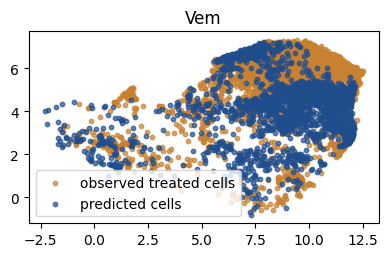

In [7]:
X_pre_COLO858, X_post_COLO858 = prepare_pair_from_mat('COLO858', 'DMSO','24h', 'Vem', '72h')
X_pre_WM902B, X_post_WM902B = prepare_pair_from_mat('WM902B', 'DMSO','24h', 'Vem', '72h')
X_pre_RVH421, X_post_RVH421 = prepare_pair_from_mat('RVH421', 'DMSO','24h', 'Vem', '72h')
X_pre_SKMEL19, X_post_SKMEL19 = prepare_pair_from_mat('SKMEL19', 'DMSO','24h', 'Vem', '72h')

drug = 'Vem'
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_WM902B, X_pre_RVH421, X_pre_SKMEL19], axis=0)
X_post_combined = np.concatenate([X_post_WM902B, X_post_RVH421, X_post_SKMEL19], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_COLO858
Y_te_post = X_post_COLO858

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = LAOT(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=1000, batch_size=2048, lr=1e-4, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post[:, jfe_indices], median_gamma)
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('test_map') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/aot_on_4i_drug_{drug}.png", dpi=300)

(6223, 20)
(5690, 20)
(6223, 20)
(5690, 20)
Median heuristic gamma: 0.06858537318932031
**************** Run: 0 ****************
Epoch 0 | Train Loss 1448.3950 | Train MMD 0.8214 | Test MMD 1.0663 
Epoch 100 | Train Loss 1290.7201 | Train MMD 0.7396 | Test MMD 0.8764 
Epoch 200 | Train Loss 885.9413 | Train MMD 0.6377 | Test MMD 0.6798 
Epoch 300 | Train Loss 855.3796 | Train MMD 0.5263 | Test MMD 0.5007 
Epoch 400 | Train Loss 609.7670 | Train MMD 0.4137 | Test MMD 0.3497 
Epoch 500 | Train Loss 597.2412 | Train MMD 0.3053 | Test MMD 0.2312 
Epoch 600 | Train Loss 391.0348 | Train MMD 0.2171 | Test MMD 0.1649 
Epoch 700 | Train Loss 444.4369 | Train MMD 0.1531 | Test MMD 0.1413 
Epoch 800 | Train Loss 313.0360 | Train MMD 0.1094 | Test MMD 0.1428 
Epoch 900 | Train Loss 296.8307 | Train MMD 0.0805 | Test MMD 0.1557 
Epoch 1000 | Train Loss 340.9709 | Train MMD 0.0617 | Test MMD 0.1709 


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


Test MMD: 0.1709
Test Wasserstein: 1.7749


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


                        mean  std
mmd2_gamma_median     0.1709  NaN
mmd2_gamma_0.5        0.2841  NaN
mmd2_gamma_1.0        0.2002  NaN
wasserstein_distance  1.7749  NaN
R2_feature_means      0.7263  NaN


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


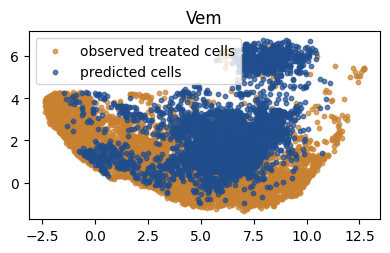

In [8]:

drug = 'Vem'
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_COLO858, X_pre_RVH421, X_pre_SKMEL19], axis=0)
X_post_combined = np.concatenate([X_post_COLO858, X_post_RVH421, X_post_SKMEL19], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_WM902B
Y_te_post = X_post_WM902B

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = LAOT(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=1000, batch_size=2048, lr=1e-4, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post[:, jfe_indices], median_gamma)
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('test_map') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/aot_on_4i_drug_{drug}.png", dpi=300)

(11393, 20)
(520, 20)
(11393, 20)
(520, 20)
Median heuristic gamma: 0.058443010817015494
**************** Run: 0 ****************
Epoch 0 | Train Loss 22731.4238 | Train MMD 0.8372 | Test MMD 0.7592 
Epoch 100 | Train Loss 14689.8740 | Train MMD 0.6457 | Test MMD 0.6018 
Epoch 200 | Train Loss 9686.1367 | Train MMD 0.4425 | Test MMD 0.4610 
Epoch 300 | Train Loss 6228.2358 | Train MMD 0.2641 | Test MMD 0.3434 
Epoch 400 | Train Loss 4121.1226 | Train MMD 0.1423 | Test MMD 0.2561 
Epoch 500 | Train Loss 3051.5315 | Train MMD 0.0752 | Test MMD 0.1970 
Epoch 600 | Train Loss 2505.3611 | Train MMD 0.0423 | Test MMD 0.1592 
Epoch 700 | Train Loss 2351.4160 | Train MMD 0.0271 | Test MMD 0.1359 
Epoch 800 | Train Loss 2042.9983 | Train MMD 0.0201 | Test MMD 0.1209 
Epoch 900 | Train Loss 1870.4949 | Train MMD 0.0162 | Test MMD 0.1092 
Epoch 1000 | Train Loss 1852.5992 | Train MMD 0.0136 | Test MMD 0.0987 
Test MMD: 0.0987
Test Wasserstein: 1.4282
                        mean  std
mmd2_gamma_m

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

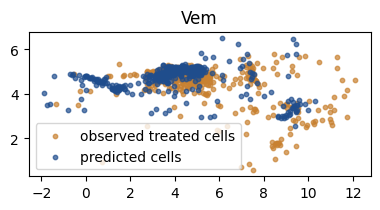

In [9]:

drug = 'Vem'
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_COLO858, X_pre_WM902B, X_pre_SKMEL19], axis=0)
X_post_combined = np.concatenate([X_post_COLO858, X_post_WM902B, X_post_SKMEL19], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_RVH421
Y_te_post = X_post_RVH421

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = LAOT(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=1000, batch_size=2048, lr=1e-4, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post[:, jfe_indices], median_gamma)
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('test_map') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/aot_on_4i_drug_{drug}.png", dpi=300)

(9236, 20)
(2677, 20)
(9236, 20)
(2677, 20)
Median heuristic gamma: 0.05359678257926303
**************** Run: 0 ****************
Epoch 0 | Train Loss 23473.7168 | Train MMD 0.9328 | Test MMD 0.5317 
Epoch 100 | Train Loss 15844.7842 | Train MMD 0.7406 | Test MMD 0.5009 
Epoch 200 | Train Loss 10794.4561 | Train MMD 0.5434 | Test MMD 0.4626 
Epoch 300 | Train Loss 7303.2251 | Train MMD 0.3672 | Test MMD 0.4222 
Epoch 400 | Train Loss 5280.0015 | Train MMD 0.2268 | Test MMD 0.3832 
Epoch 500 | Train Loss 3774.7310 | Train MMD 0.1308 | Test MMD 0.3481 
Epoch 600 | Train Loss 2799.9707 | Train MMD 0.0718 | Test MMD 0.3185 
Epoch 700 | Train Loss 2285.8728 | Train MMD 0.0385 | Test MMD 0.2949 
Epoch 800 | Train Loss 1996.3676 | Train MMD 0.0211 | Test MMD 0.2771 
Epoch 900 | Train Loss 1881.5461 | Train MMD 0.0125 | Test MMD 0.2639 
Epoch 1000 | Train Loss 1627.1217 | Train MMD 0.0083 | Test MMD 0.2542 


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


Test MMD: 0.2542
Test Wasserstein: 2.2603


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/ot/lp/_network_simplex.py:332: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


                        mean  std
mmd2_gamma_median     0.2542  NaN
mmd2_gamma_0.5        0.2848  NaN
mmd2_gamma_1.0        0.1658  NaN
wasserstein_distance  2.2603  NaN
R2_feature_means     -0.9802  NaN


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


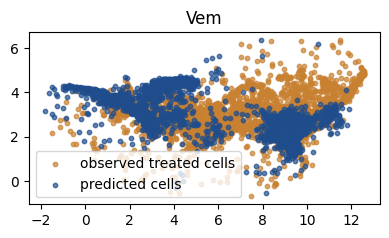

In [10]:

drug = 'Vem'
jfe_indices = [1, 6, 0, 5, 4, 7, 8, 2, 3, 19]

X_pre_combined = np.concatenate([X_pre_COLO858, X_pre_WM902B, X_pre_RVH421], axis=0)
X_post_combined = np.concatenate([X_post_COLO858, X_post_WM902B, X_post_RVH421], axis=0)


X_tr_pre = X_pre_combined
Y_tr_post = X_post_combined
X_te_pre = X_pre_SKMEL19
Y_te_post = X_post_SKMEL19

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)

all_metrics = []
for run in range(1):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = LAOT(X_tr_pre[:, jfe_indices], Y_tr_post[:, jfe_indices], X_te_pre[:, jfe_indices], Y_te_post[:, jfe_indices], n_epochs=1000, batch_size=2048, lr=1e-4, seed=seed, device="auto", verbose=True)
    print(f"Test MMD: {out['test_mmd']:.4f}")
    print(f"Test Wasserstein: {out['test_wasserstein']:.4f}")
    metrics = summarize_metrics(out["test_map"], Y_te_post[:, jfe_indices], median_gamma)
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))


from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post[:, jfe_indices]
target = Y_te_post[:, jfe_indices]
predicted = out.get('test_map') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C88131")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/aot_on_4i_drug_{drug}.png", dpi=300)